Bu projede BBC haber veri seti kullanılarak haber metinlerinin kategorilere göre sınıflandırılması amaçlanmıştır. Veri setinde business, entertainment, politics, sport ve tech olmak üzere beş farklı haber kategorisi yer almaktadır. Proje kapsamında metin ön işleme, stopwords temizleme, TF-IDF vektörleştirme ve makine öğrenmesi modelleri uygulanmıştır. 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bbc-news-data.csv",sep="\t")

df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [3]:
df.shape

(2225, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   filename  2225 non-null   object
 2   title     2225 non-null   object
 3   content   2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB


In [5]:
df.isnull().sum()

category    0
filename    0
title       0
content     0
dtype: int64

In [6]:
df["category"].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

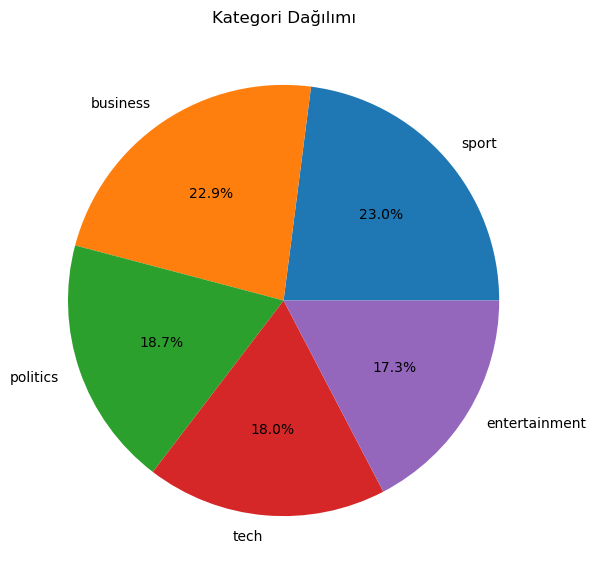

In [7]:
import matplotlib.pyplot as plt
df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Kategori Dağılımı")

plt.show()

In [8]:
#Başlık ve içerik sütunlarını birleştiriyoruz.
df["text"] = df["title"] + " " + df["content"]

df.head()

,category,filename,title,content,text
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,Ad sales boost Time Warner profit Quarterly p...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,Dollar gains on Greenspan speech The dollar h...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,Yukos unit buyer faces loan claim The owners ...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,High fuel prices hit BA's profits British Air...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,Pernod takeover talk lifts Domecq Shares in U...


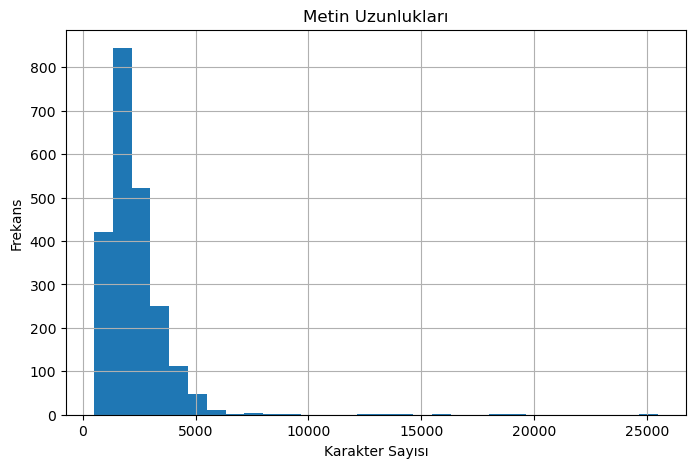

In [9]:
#Metin uzunluklarını inceliyoruz.
df["text_length"] = df["text"].apply(len)

df["text_length"].hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Metin Uzunlukları")
plt.xlabel("Karakter Sayısı")
plt.ylabel("Frekans")

plt.show()

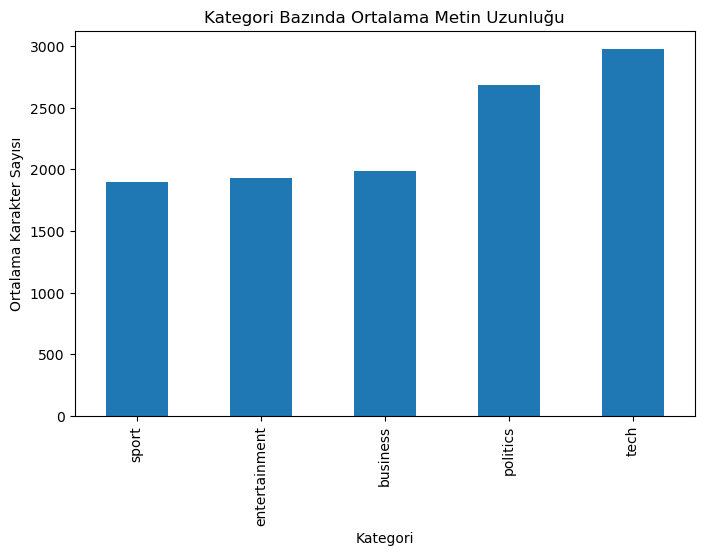

In [10]:
#Kategori bazında ortalama metin uzunluklarını karşılaştırıyoruz.
df.groupby("category")["text_length"].mean().sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Kategori Bazında Ortalama Metin Uzunluğu")
plt.xlabel("Kategori")
plt.ylabel("Ortalama Karakter Sayısı")

plt.show()

In [11]:
df["text"].head()

0    Ad sales boost Time Warner profit  Quarterly p...
1    Dollar gains on Greenspan speech  The dollar h...
2    Yukos unit buyer faces loan claim  The owners ...
3    High fuel prices hit BA's profits  British Air...
4    Pernod takeover talk lifts Domecq  Shares in U...
Name: text, dtype: object

In [12]:
#Kelime sayısı dağılımına bakıyoruz.
df["word_count"] = df["text"].apply(
    lambda x: len(str(x).split())
)

df["word_count"].describe()

count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64

In [18]:
#stopwordslerş ve tahminde işe yaramayacak kelimleri temziliyoruz
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

extra_words = {
    "said", "mr", "mrs", "new", "year", "years",
    "people", "time", "world", "uk", "just",
    "make", "told", "best", "bn", "like"
}

stop_words = set(ENGLISH_STOP_WORDS).union(extra_words)

def temizle(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    words = [
        word
        for word in text.split()
        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(temizle)

In [19]:
# En çok kullanılan 20 kelimeyi inceliyoruz.
from collections import Counter

words = " ".join(df["clean_text"]).split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

top_words_df = pd.DataFrame(
    top_words,
    columns=["Kelime", "Frekans"]
)

top_words_df

,Kelime,Frekans
0,government,1160
1,film,890
2,game,871
3,music,839
4,labour,804
5,bbc,778
6,set,762
7,number,760
8,way,740
9,added,733


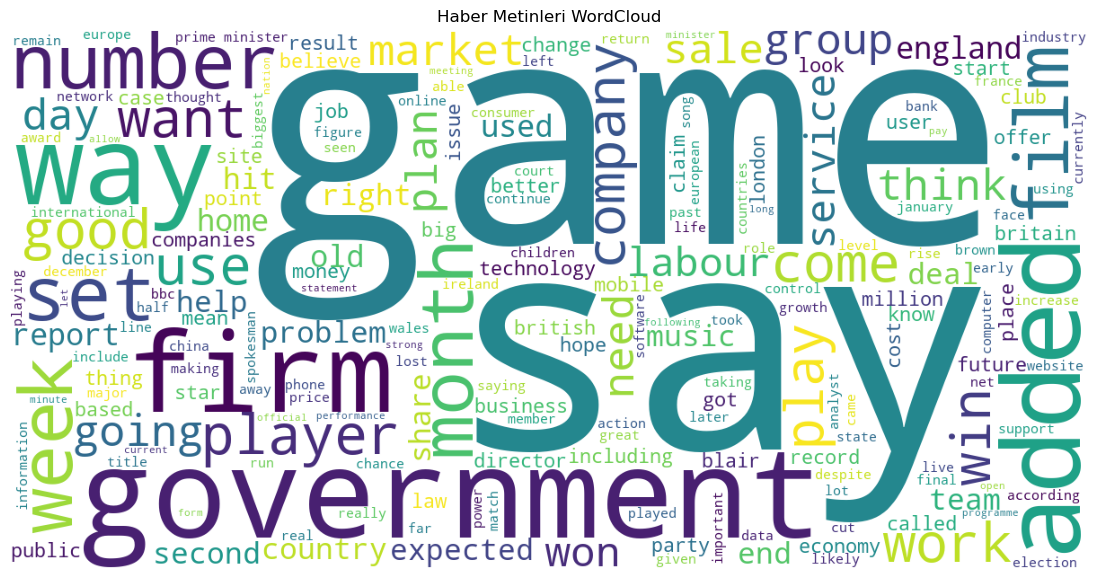

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Haber Metinleri WordCloud")
plt.show()

In [21]:
#Metinleri sayısal hale getirmek için TF-IDF uyguluyoruz.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

x = tfidf.fit_transform(df["clean_text"])

x.shape

(2225, 5000)

In [26]:
#Hedef değişkenimizi oluşturuyoruz.
y = df["category"]

y.sample(5)

1058    politics
48      business
178     business
1166    politics
405     business
Name: category, dtype: object

In [27]:
#Veriyi eğitim ve test olarak ayırıyoruz.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print(x_train.shape)
print(x_test.shape)

(1780, 5000)
(445, 5000)


In [28]:
#İlk model olarak Multinomial Naive Bayes kuruyoruz.
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(x_train, y_train)

MultinomialNB()

In [30]:
#Tahminleri üretiyoruz.
pred = model.predict(x_test)

In [31]:
#Başarı oranını hesaplıyoruz.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9707865168539326


In [32]:
#Confusion Matrix oluşturuyoruz.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

cm

array([[110,   0,   3,   0,   2],
       [  1,  68,   2,   0,   1],
       [  1,   0,  74,   0,   1],
       [  1,   0,   0, 101,   0],
       [  0,   1,   0,   0,  79]])

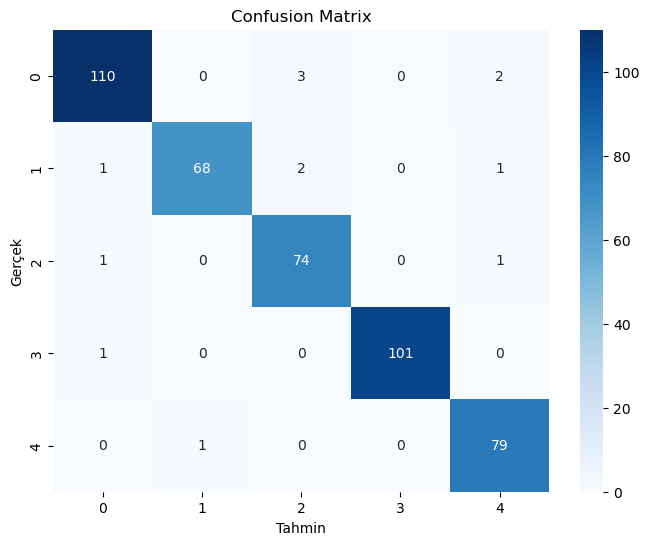

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

plt.show()

In [35]:
#Sınıf bazlı başarıları inceliyoruz.
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

               precision    recall  f1-score   support

     business       0.97      0.96      0.96       115
entertainment       0.99      0.94      0.96        72
     politics       0.94      0.97      0.95        76
        sport       1.00      0.99      1.00       102
         tech       0.95      0.99      0.97        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



In [36]:
#Logistic Regression modeli kuruyoruz.
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

In [37]:
lr_score = accuracy_score(y_test, lr_pred)

In [38]:
lr_score

0.9730337078651685

In [41]:
#Sonuçları karşılaştırıyoruz.
from sklearn.metrics import accuracy_score

nb_score = accuracy_score(y_test, pred)

lr_score = accuracy_score(y_test, lr_pred)

sonuc = pd.DataFrame({
    "Model":["MultinomialNB","LogisticRegression"],
    "Accuracy":[nb_score, lr_score]
})

sonuc

,Model,Accuracy
0,MultinomialNB,0.970787
1,LogisticRegression,0.973034


In [42]:
#En başarılı modeli kaydediyoruz.
import joblib

joblib.dump(lr_model,"news_category_model.pkl")

['news_category_model.pkl']

In [43]:
#Yeni haberleri aynı şekilde dönüştürebilmek için TF-IDF nesnesini kaydediyoruz.
joblib.dump(tfidf,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [45]:
#Modelin yeni bir haber üzerinde nasıl çalıştığını test ediyoruz.
haber = """
Manchester United won the match after scoring two goals in the second half.
"""

haber_tf = tfidf.transform([haber])

tahmin = lr_model.predict(haber_tf)

print(tahmin[0])

sport


In [46]:
haberler = [
    "Apple introduced a new artificial intelligence feature for iPhone users.",
    "The government announced new economic reforms.",
    "The actor received an award for his latest movie."
]

haberler_tf = tfidf.transform(haberler)

tahminler = lr_model.predict(haberler_tf)

for haber, kategori in zip(haberler, tahminler):
    print(kategori)

tech
business
entertainment


Yapılan analiz sonucunda haber metinlerinin TF-IDF yöntemi ile başarılı şekilde sayısallaştırılabildiği ve makine öğrenmesi modelleriyle yüksek doğruluk oranı elde edildiği görülmüştür. Multinomial Naive Bayes modeli yaklaşık %97,08 doğruluk sağlarken Logistic Regression modeli yaklaşık %97,30 doğruluk oranı ile daha başarılı sonuç vermiştir. Bu nedenle nihai model olarak Logistic Regression seçilmiştir. Proje, NLP tekniklerinin haber metinlerini otomatik olarak sınıflandırmada etkili biçimde kullanılabileceğini göstermektedir.